## Project Overview

This project analyzes a global retail business using transactional sales, customer, product, store, and exchange rate data. The objective is to transform raw data into meaningful business insights by performing data cleaning, feature engineering, exploratory data analysis (EDA), SQL-based business analysis, and interactive Power BI dashboard development.

The project demonstrates an end-to-end data analytics workflow using Python, SQL, and Power BI.

## Business Objective

The primary objective of this project is to help retail management make data-driven decisions by identifying sales trends, customer purchasing behavior, product performance, and store efficiency.

The analysis aims to answer important business questions related to revenue growth, profitability, customer segmentation, inventory performance, and geographical sales distribution.

## Dataset Description

Customers - Customer demographic information
Products - Product details including pricing and categories
Sales - Transaction-level sales data
Stores - Store information including location and size
Exchange Rates - Daily exchange rates for multiple currencies

### Import Libraries and Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customer_df = pd.read_csv('DataSet/Customers.csv',encoding='latin1')
exchange_df = pd.read_csv('DataSet/Exchange_Rates.csv')
products_df = pd.read_csv('DataSet/Products.csv')
sales_df = pd.read_csv('DataSet/Sales.csv')
stores_df = pd.read_csv('Dataset/Stores.csv')


### Inspecting the Data

In [2]:
datasets = {
    "Customers": customer_df,
    "Products": products_df,
    "Sales": sales_df,
    "Stores": stores_df,
    "Exchange Rates": exchange_df
}

for name, df in datasets.items():
    print("="*70)
    print(name.upper())
    print("="*70)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 Rows:")
    display(df.head())

CUSTOMERS

Shape:
(15266, 10)

Columns:
['CustomerKey', 'Gender', 'Name', 'City', 'State Code', 'State', 'Zip Code', 'Country', 'Continent', 'Birthday']

First 5 Rows:


,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965


PRODUCTS

Shape:
(2517, 10)

Columns:
['ProductKey', 'Product Name', 'Brand', 'Color', 'Unit Cost USD', 'Unit Price USD', 'SubcategoryKey', 'Subcategory', 'CategoryKey', 'Category']

First 5 Rows:


,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio


SALES

Shape:
(62884, 9)

Columns:
['Order Number', 'Line Item', 'Order Date', 'Delivery Date', 'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code']

First 5 Rows:


,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD


STORES

Shape:
(67, 5)

Columns:
['StoreKey', 'Country', 'State', 'Square Meters', 'Open Date']

First 5 Rows:


,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.0,1/1/2008
1,2,Australia,Northern Territory,665.0,1/12/2008
2,3,Australia,South Australia,2000.0,1/7/2012
3,4,Australia,Tasmania,2000.0,1/1/2010
4,5,Australia,Victoria,2000.0,12/9/2015


EXCHANGE RATES

Shape:
(11215, 3)

Columns:
['Date', 'Currency', 'Exchange']

First 5 Rows:


,Date,Currency,Exchange
0,1/1/2015,USD,1.0000
1,1/1/2015,CAD,1.1583
2,1/1/2015,AUD,1.2214
3,1/1/2015,EUR,0.8237
4,1/1/2015,GBP,0.6415


### Checking Dataset information

In [3]:
for name,df in datasets.items():
    print(f"\n{name}")
    print("-"*60)
    df.info()


Customers
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CustomerKey  15266 non-null  int64
 1   Gender       15266 non-null  str  
 2   Name         15266 non-null  str  
 3   City         15266 non-null  str  
 4   State Code   15256 non-null  str  
 5   State        15266 non-null  str  
 6   Zip Code     15266 non-null  str  
 7   Country      15266 non-null  str  
 8   Continent    15266 non-null  str  
 9   Birthday     15266 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1.2 MB

Products
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProductKey      2517 non-null   int64
 1   Pro

### Data Cleaning

#### Checking the duplicates

In [4]:
for name,df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicated rows")

Customers: 0 duplicated rows
Products: 0 duplicated rows
Sales: 0 duplicated rows
Stores: 0 duplicated rows
Exchange Rates: 0 duplicated rows


#### Converting Date Columns

In [5]:
customer_df['Birthday'] = pd.to_datetime(customer_df['Birthday'])
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])
sales_df['Delivery Date'] = pd.to_datetime(sales_df['Delivery Date'])
stores_df['Open Date'] = pd.to_datetime(stores_df['Open Date'])
exchange_df['Date'] = pd.to_datetime(exchange_df['Date'])

#### Cleaning Product Prices

In [6]:
products_df['Unit Cost USD'] = (
    products_df['Unit Cost USD'].str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
    .astype(float)
)

products_df['Unit Price USD'] = (
    products_df['Unit Price USD'].str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
    .astype(float)
)

#### Handling Missing Values

In [7]:
customer_df['State Code'] = customer_df['State Code'].fillna('Unknown')
stores_df["Square Meters"] = stores_df["Square Meters"].fillna(
    stores_df["Square Meters"].median()
)
sales_df["Delivery Date"].isnull().mean()*100

np.float64(79.064626932129)

### Adding New columns

In [8]:
from datetime import datetime

today = pd.Timestamp.today()

customer_df["Age"] = (
    (today - customer_df["Birthday"]).dt.days // 365
)
print(customer_df['Age'])

customer_df["Age Group"] = pd.cut(
    customer_df["Age"],
    bins=[0,18,25,35,45,55,65,100],
    labels=["<18","18-25","26-35","36-45","46-55","56-65","65+"]
)

0        87
1        46
2        79
3        68
4        60
         ..
15261    90
15262    34
15263    88
15264    88
15265    60
Name: Age, Length: 15266, dtype: int64


#### Exporting cleaned data to csv

In [21]:
customer_df.to_csv("DataSet/Customers_cleaned.csv", index=False)

exchange_df.to_csv("DataSet/Exchange_Rates_cleaned.csv", index=False)

products_df.to_csv("DataSet/Products_cleaned.csv", index=False)

sales_df.to_csv("DataSet/Sales_cleaned.csv", index=False)

stores_df.to_csv("DataSet/Stores_cleaned.csv", index=False)

### Merging the datasets

In [9]:
final_df = sales_df.merge(customer_df,how ="left",on="CustomerKey")
final_df = final_df.merge(products_df,on="ProductKey",how="left")
final_df = final_df.merge(stores_df,on="StoreKey",how="left")
final_df = final_df.merge(
    exchange_df,
    left_on=["Order Date", "Currency Code"],
    right_on=["Date", "Currency"],
    how="left"
)

### Adding Business Metrics

In [10]:
final_df["Revenue"] = final_df["Quantity"] * final_df["Unit Price USD"]
final_df["Cost"] = final_df["Quantity"] * final_df["Unit Cost USD"]
final_df["Profit"] = final_df["Revenue"] - final_df["Cost"]
final_df["Profit Margin"] =(
    final_df["Profit"]/final_df["Revenue"]
)*100

### Exploratory Data Analysis

#### Top - 10 Products by Revenue

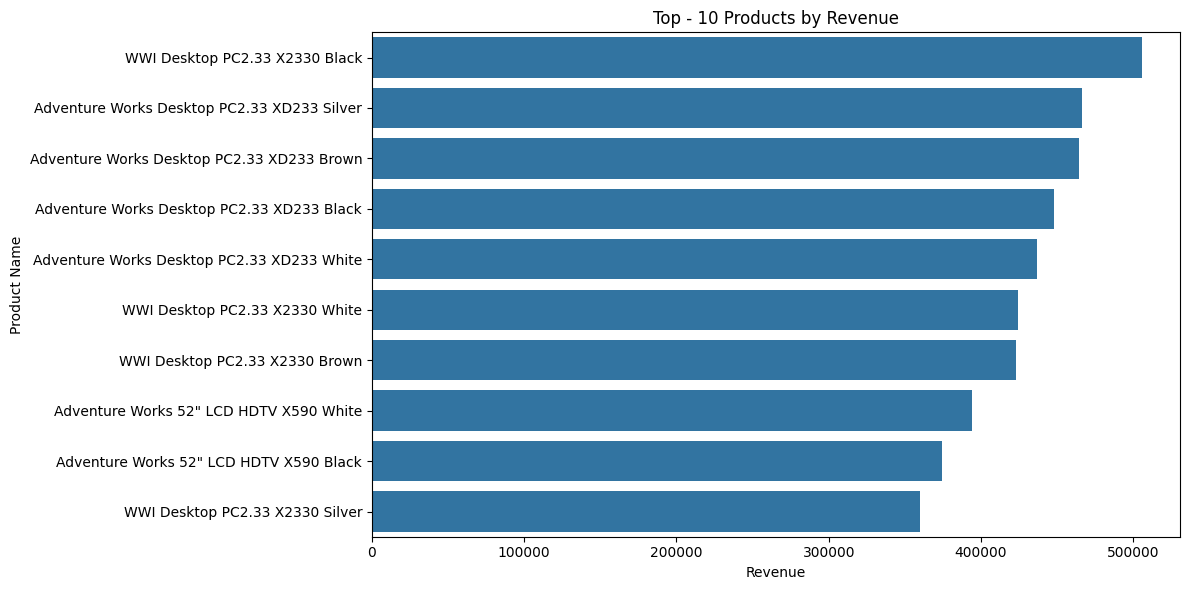

In [11]:
plt.figure(figsize=(12,6))
top_products = (final_df.groupby('Product Name')['Revenue'].sum()
                .sort_values(ascending=False)
                .head(10).reset_index()
)

sns.barplot(data=top_products, y="Product Name", x="Revenue")
plt.title("Top - 10 Products by Revenue")
plt.tight_layout()
plt.show()

#### Insight
WWI Desktop PC is the top-selling product with the highest revenue, followed by the Adventure Works Desktop. This indicates that customers prefer high-end electronics, which can inform future inventory and marketing strategies.

#### Revenue by Category

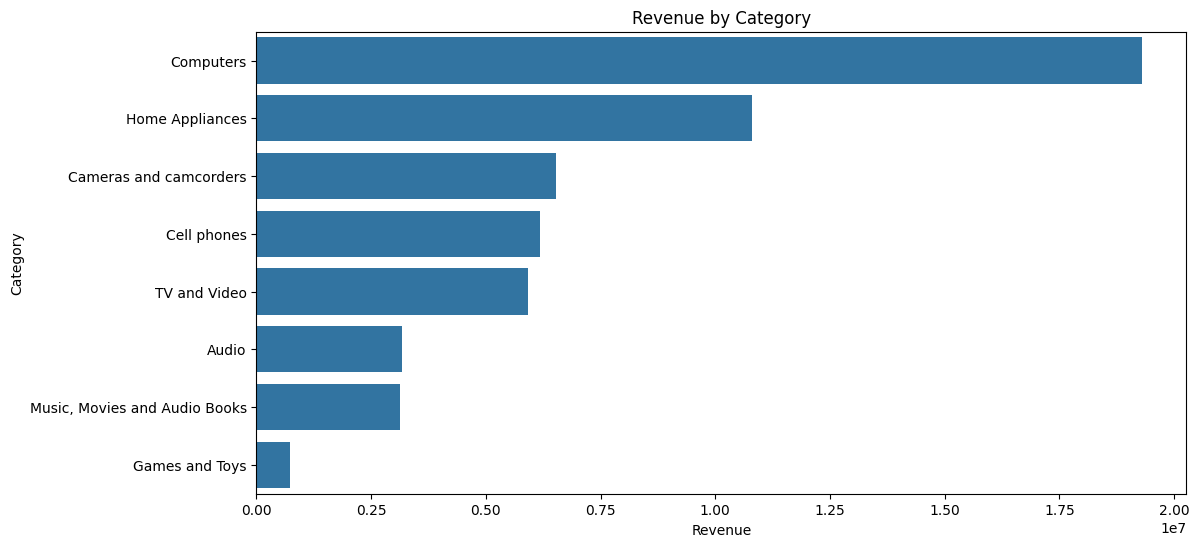

In [12]:
revenue_by_category = ( final_df.groupby('Category')['Revenue']
                       .sum().reset_index()
                       .sort_values(by="Revenue",ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(data=revenue_by_category, y="Category", x="Revenue")
plt.title("Revenue by Category")
plt.show()

#### Insight
Computers and Appliances are the top two categories contributing to the highest revenue, indicating a strong demand for these product types. Retail management can focus on expanding product offerings in these categories to maximize sales.

#### Revenue by Country

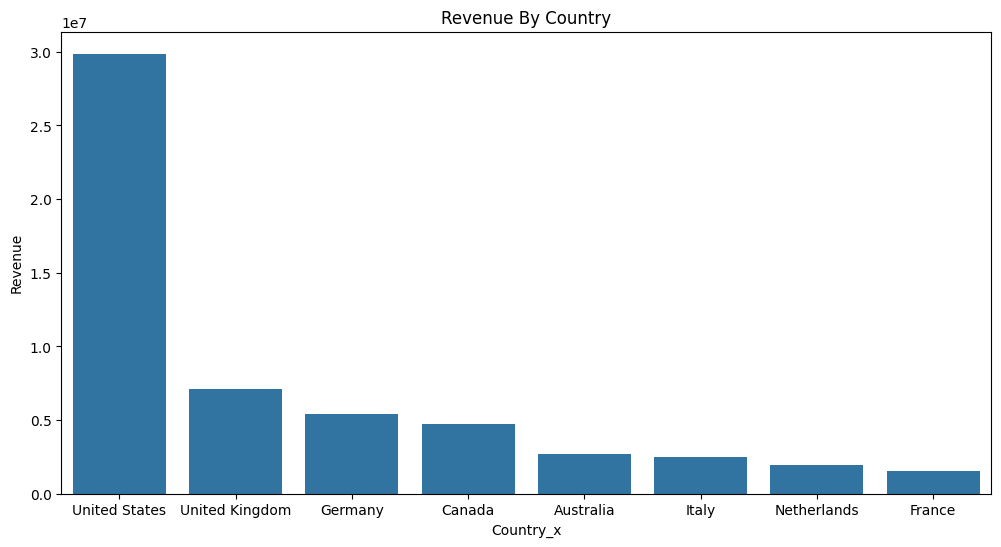

In [13]:
revenue_by_country = (
    final_df.groupby("Country_x")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=revenue_by_country,x='Country_x',y='Revenue')
plt.title('Revenue By Country')
plt.show()



#### Insight
United States is the leading country in terms of revenue, followed by the United Kingdom and Germany. This suggests that the retail business has a strong presence in North America and Europe, which can guide future market expansion strategies.

#### Revenue by Year

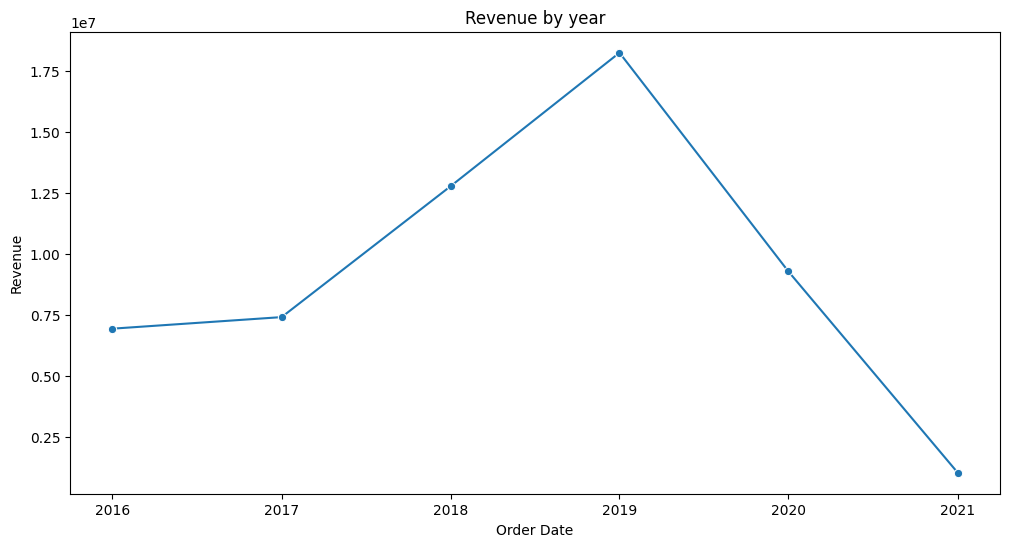

In [14]:
final_df["Order Date"] = pd.to_datetime(final_df["Order Date"])

revenue_by_year = (
    final_df.groupby(final_df['Order Date'].dt.to_period('Y'))['Revenue']
    .sum().reset_index()
)

revenue_by_year["Order Date"] = revenue_by_year["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12,6))
sns.lineplot(data=revenue_by_year,x='Order Date',y='Revenue',marker='o')
plt.title('Revenue by year')
plt.show()

#### Insight
A steady growth in revenue is observed from 2015-2019,with a significant drop in 2020 due to the COVID-19 pandemic. This highlights the impact of global events on retail sales and emphasizes the need for contingency planning and diversification of sales channels.

#### Customer Age Distribution

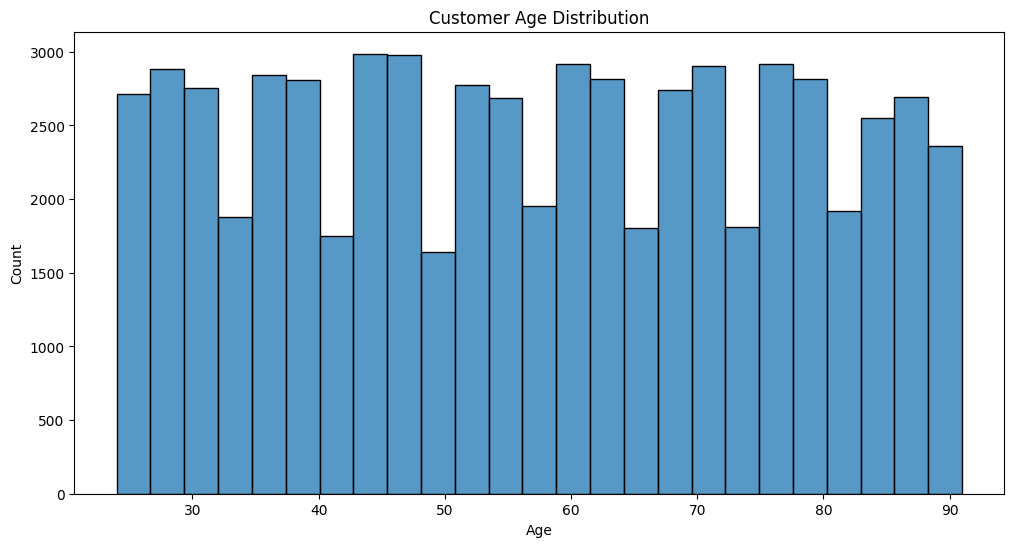

In [15]:
plt.figure(figsize=(12,6))
sns.histplot(data=final_df,x='Age',bins=25)
plt.title("Customer Age Distribution")
plt.show()

#### Insight
CustomerAge distribution shows that the majority of customers fall within the 30-50 age range, indicating that marketing strategies should target this demographic for maximum engagement and sales.

#### Top Customers by Revenue

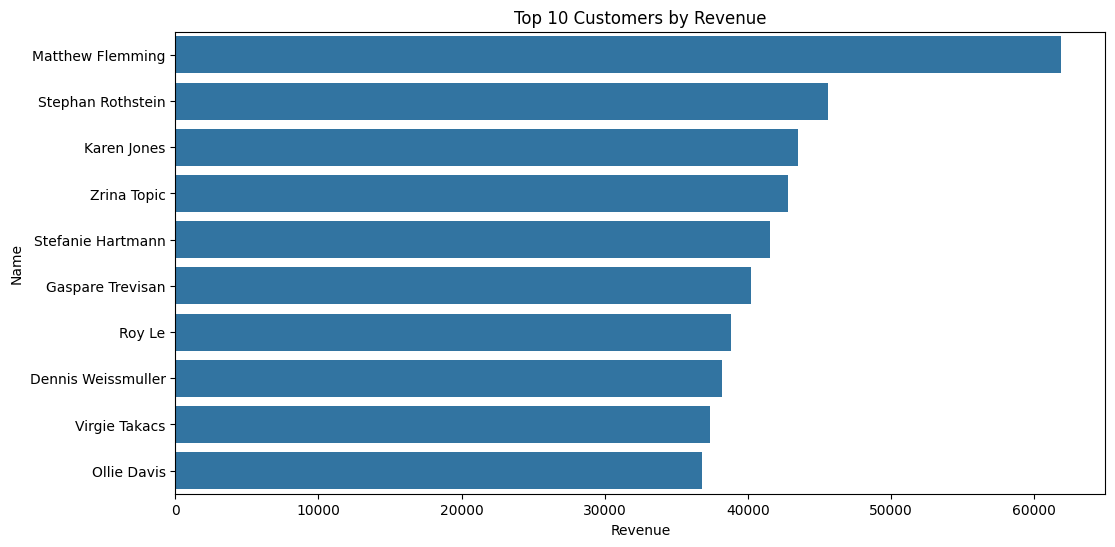

In [16]:
top_customers = (
    final_df.groupby('Name')['Revenue'].sum()
    .sort_values(ascending=False).head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=top_customers,y='Name',x='Revenue')
plt.title("Top 10 Customers by Revenue")    
plt.show()


#### Insight
Mathhew Flemming is the top customer by revenue, followed by Stephan Rothstein and Karen Janes. This indicates that a small number of customers contribute significantly to the overall revenue, highlighting the importance of customer retention strategies for high-value clients.

#### Profit Distribution

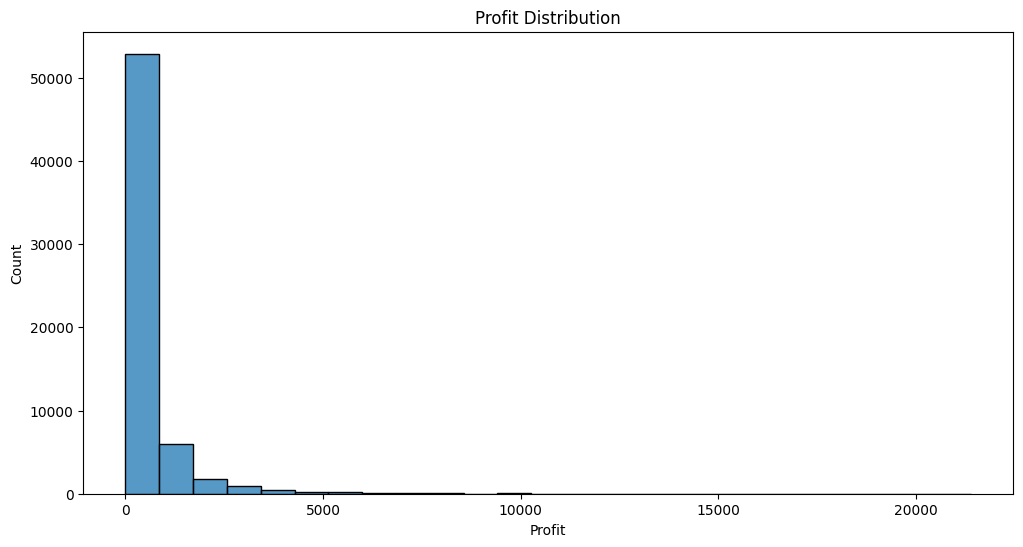

In [17]:
plt.figure(figsize=(12,6))
sns.histplot(data=final_df,x='Profit',bins=25)
plt.title("Profit Distribution")
plt.show()

#### Insight
Profit distribution analysis reveals that while some products generate high revenue, they may not be the most profitable. This insight can help retail management focus on products that offer better profit margins, optimizing overall profitability.

#### Profit By Category

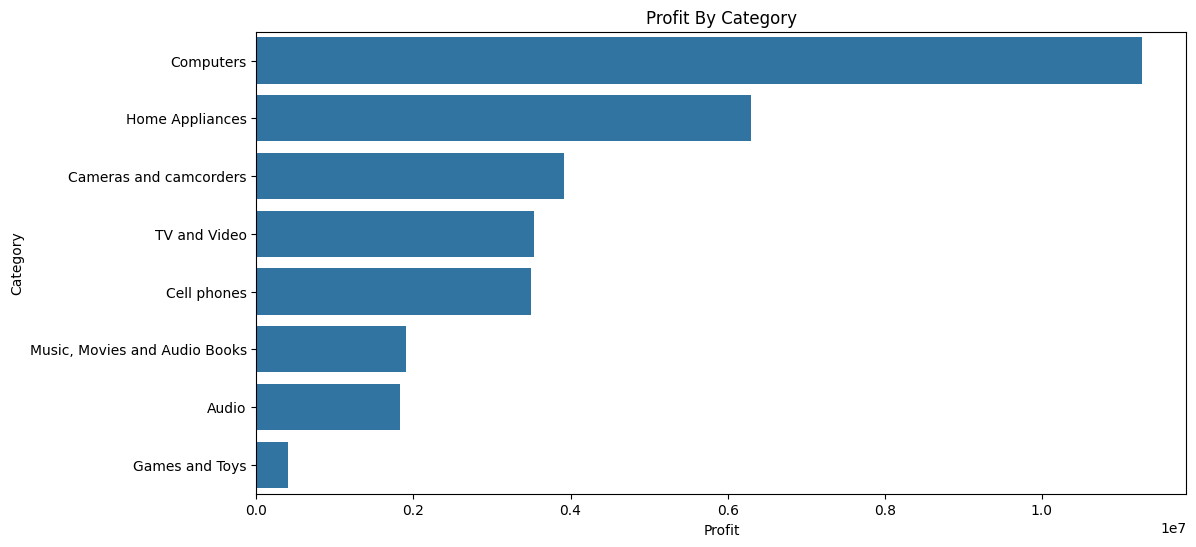

In [18]:
profit_category = (final_df.groupby('Category')['Profit'].sum()
                   .sort_values(ascending=False).head(10)
                   .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=profit_category,y='Category',x='Profit')
plt.title("Profit By Category")
plt.show()

#### Insight
Computers and Appliances are the top profit and revenue-generating categories, indicating that these product types are not only popular but also profitable. Retail management can prioritize these categories for future growth and marketing efforts.

#### Correlation heatmap for numeric columns

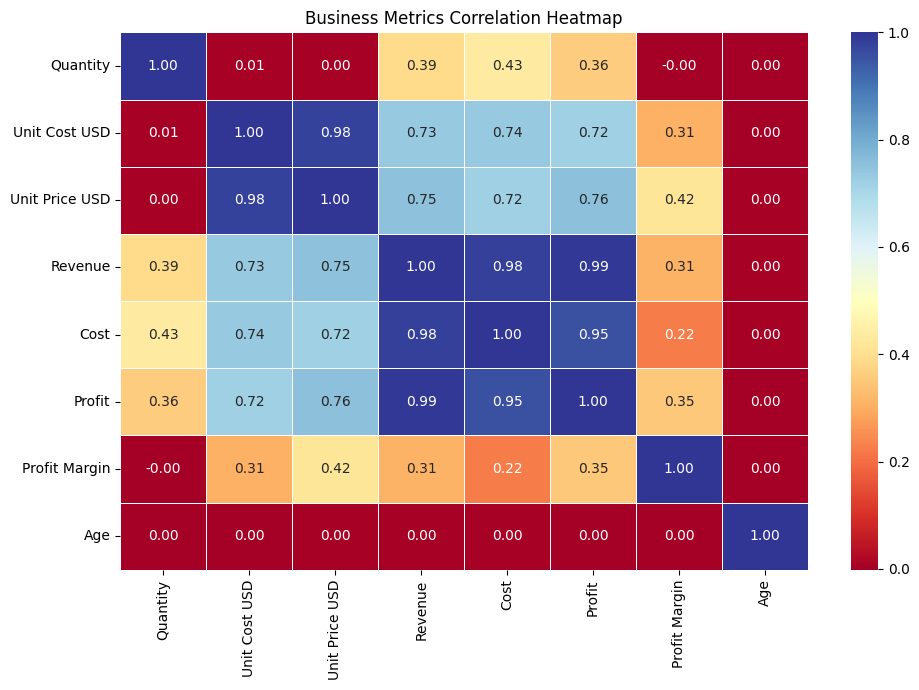

In [19]:
corr = final_df[
    [
        "Quantity",
        "Unit Cost USD",
        "Unit Price USD",
        "Revenue",
        "Cost",
        "Profit",
        "Profit Margin",
        "Age"
    ]
].corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Business Metrics Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Insight
Correlation analysis shows a strong positive correlation between revenue and profit, indicating that as revenue increases, profit tends to increase as well. This insight can help retail management focus on strategies that drive revenue growth to enhance overall profitability.
